In [1]:
from google.colab import files

uploaded = files.upload()

Saving hictda.zip to hictda.zip


In [2]:
!unzip -q hictda.zip

In [3]:
!ls -R hictda| head -100

hictda:
docs
LICENSE.md
pyproject.toml
README.md
src
tests

hictda/docs:
methodology.md

hictda/src:
hictda

hictda/src/hictda:
cli.py
__init__.py
io.py
pipeline.py
statistics.py
topology.py
visualization.py

hictda/tests:
test_statistics.py
test_topology.py


In [4]:
%cd hictda

/content/hictda


In [5]:
!ls

docs  LICENSE.md  pyproject.toml  README.md  src  tests


In [15]:
%cd /content/hictda/src/hictda
%pip install -e /content/hictda

/content/hictda/src/hictda
Obtaining file:///content/hictda
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for hictda (pyproject.toml) ... done
  Created wheel for hictda: filename=hictda-0.1.0-0.editable-py3-none-any.whl size=4065 sha256=aa069a6bff36551d898ff31bda05d9fee3d072ccecd9cdae1284c11e12dfb613
  Stored in directory: /tmp/pip-ephem-wheel-cache-q4vnory7/wheels/2d/13/7b/8d9c4efbd2f39faef303e5fc710486273de362bce29c74ec7e
Successfully built hictda
  Attempting uninstall: hictda
    Found existing installation: hictda 0.1.0
    Uninstalling hictda-0.1.0:
      Successfully uninstalled hictda-0.1.0


In [1]:
!pip show hictda

Name: hictda
Version: 0.1.0
Summary: Persistent-homology analysis of Hi-C chromatin contact maps.
Home-page: 
Author: 
Author-email: Alamin Mustafa <alamin900005@gmail.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Editable project location: /content/hictda
Requires: hic-straw, matplotlib, numpy, persim, ripser
Required-by: 


In [2]:
%cd /content/hictda

import hictda
print(hictda.__file__)

/content/hictda
/content/hictda/src/hictda/__init__.py


In [3]:
print(hictda.__file__)

/content/hictda/src/hictda/__init__.py


{'n_h1': 15, 'mean_persistence': 0.0003241313543791572, 'median_persistence': 0.00013190123718231916, 'std_persistence': 0.00040426427286450306}


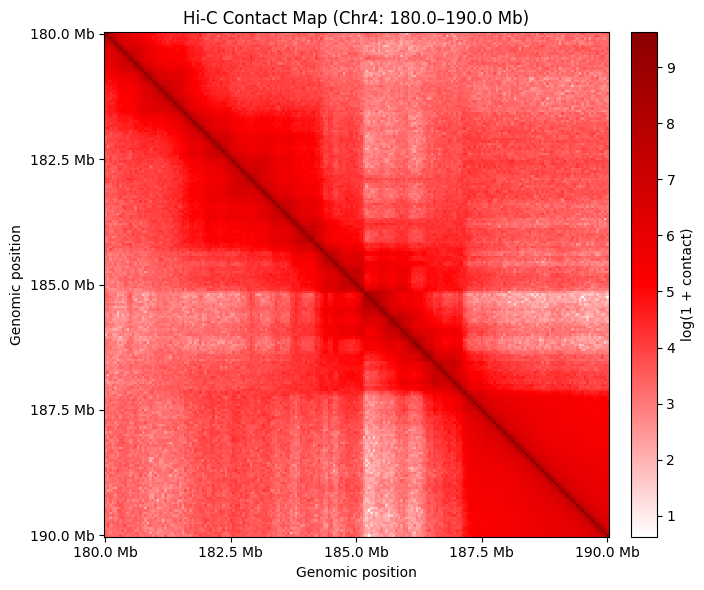

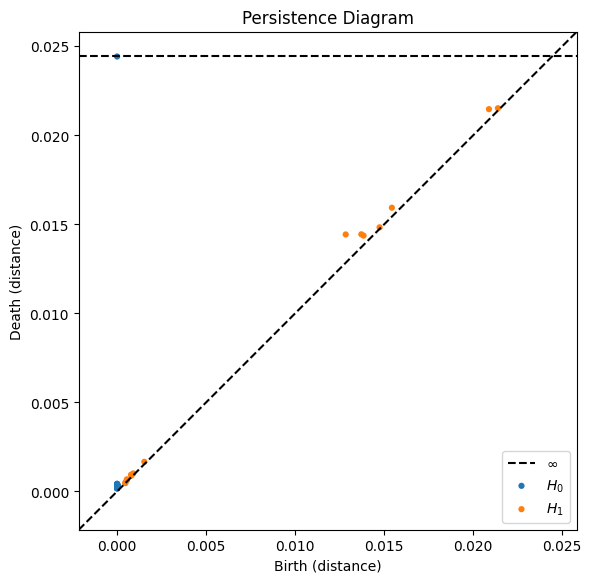

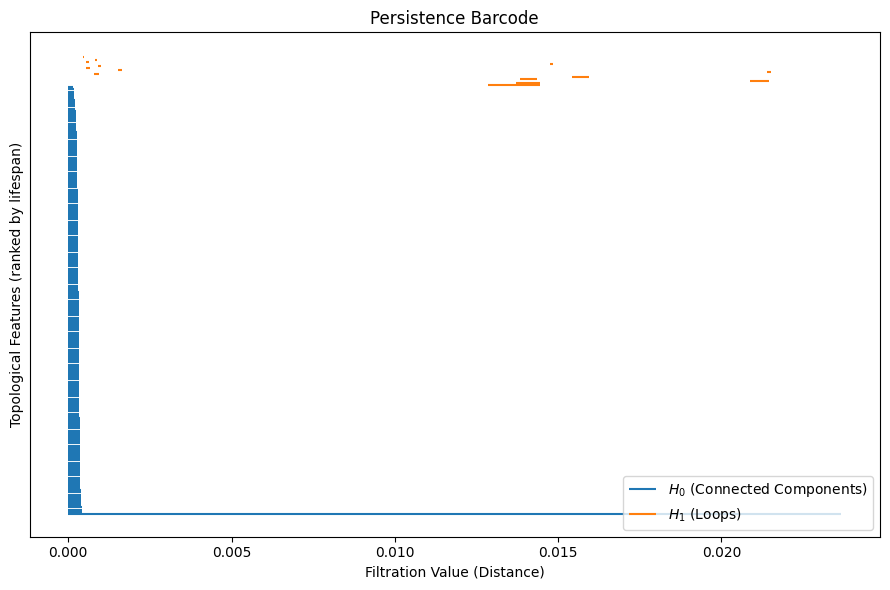

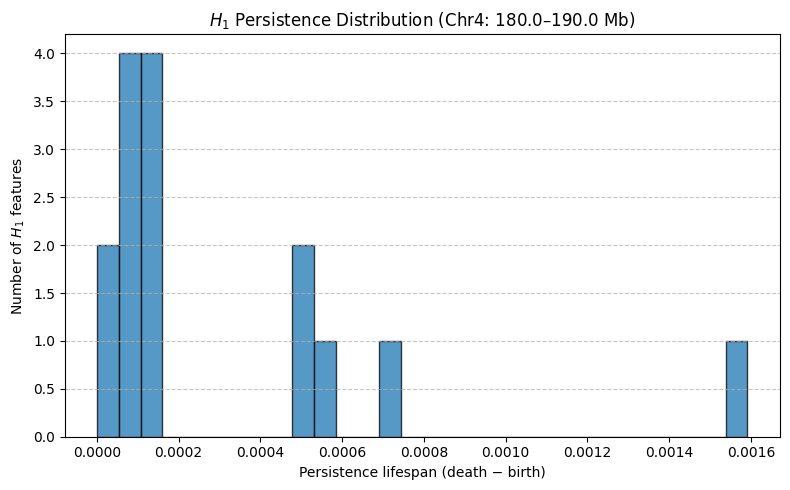

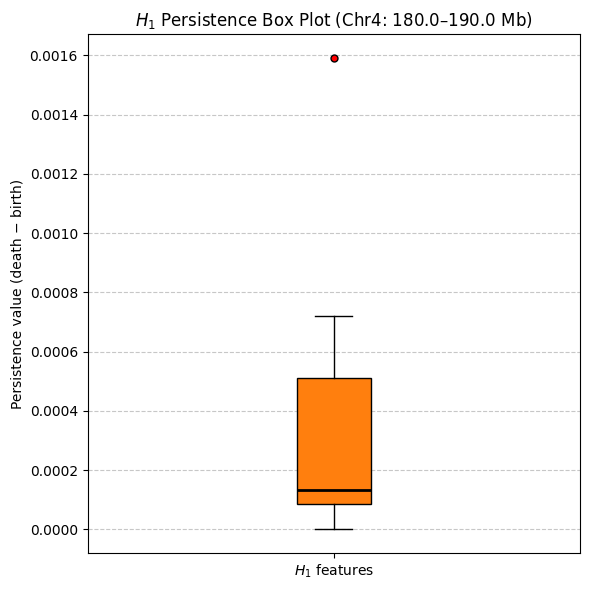

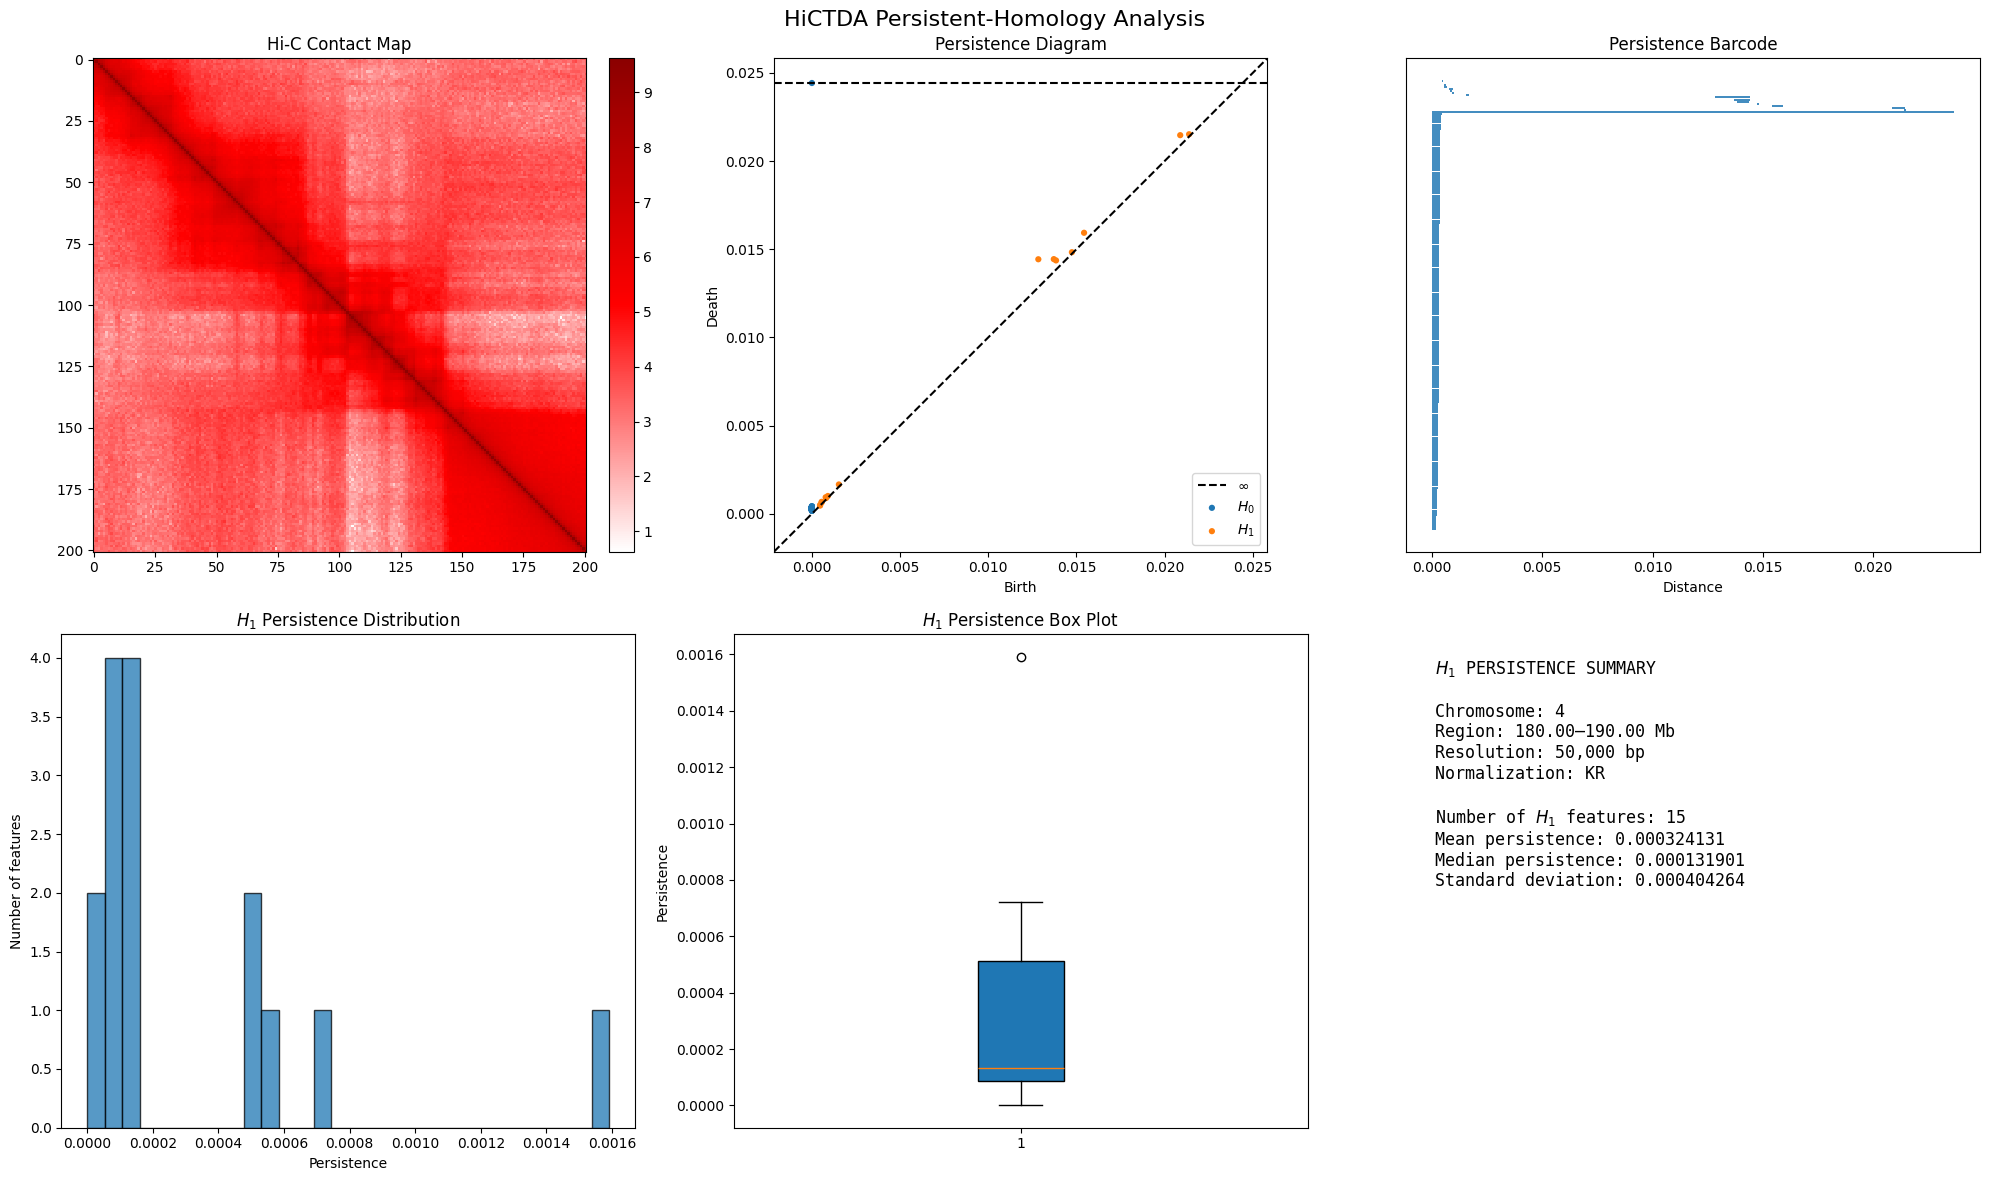

In [4]:
import sys
# Add the parent directory of the 'hictda' package to sys.path
# This is typically '/content/hictda/src' if the package is in 'hictda/src/hictda'
if '/content/hictda/src' not in sys.path:
    sys.path.insert(0, '/content/hictda/src')

import hictda.io

# Patch the _find_chromosome function to correct the AttributeError
def _find_chromosome_patched(hic, chromosome: str):
    target = str(chromosome).replace("chr", "").lower()
    # The hic.getChromosomes() method already returns a list, no need for .chromosomes
    for c in hic.getChromosomes():
        name = str(c.name)
        normalized = name.replace("chr", "").lower()
        if normalized == target:
            return c
    raise ValueError(f"Chromosome '{chromosome}' not found.")

hictda.io._find_chromosome = _find_chromosome_patched

# Now import analyze_hic and call it as intended
from hictda import analyze_hic

results = analyze_hic(
    hic_file="https://www.encodeproject.org/files/ENCFF718AWL/@@download/ENCFF718AWL.hic",
    chromosome="4",
    start=180_000_000,
    end=190_000_000,
    resolution=50_000,
    normalization="KR",
    output_dir=""
)

print(results.statistics)

{'n_h1': 5, 'mean_persistence': 0.0003251319285482168, 'median_persistence': 0.0003681026864796877, 'std_persistence': 0.00012963628187858767}


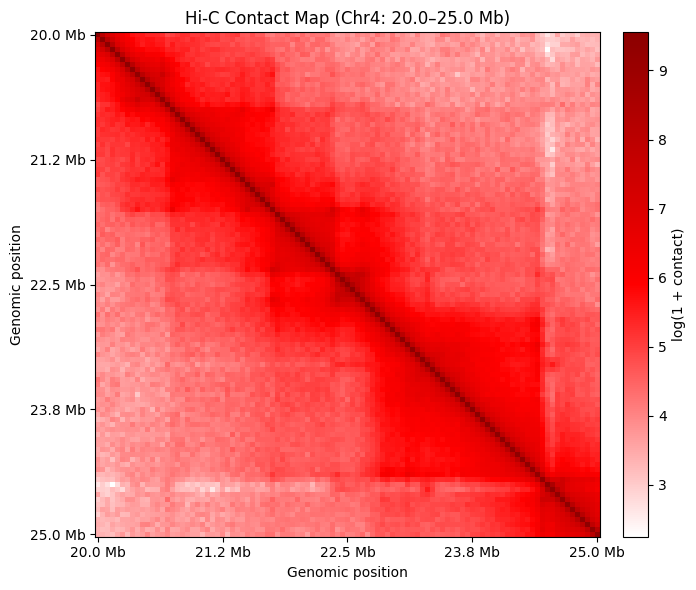

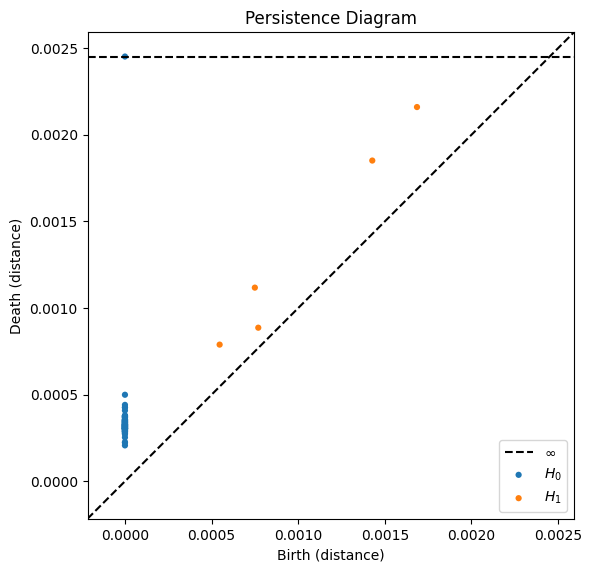

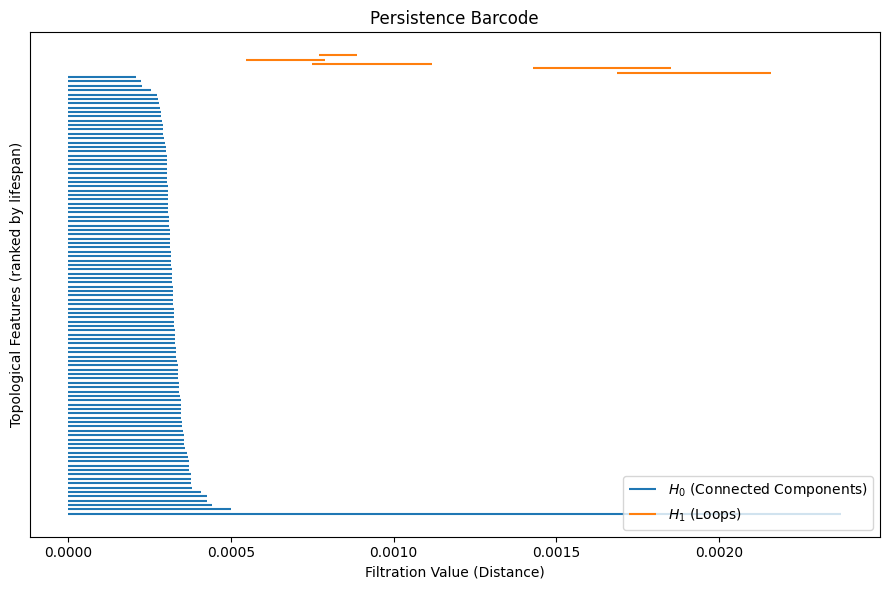

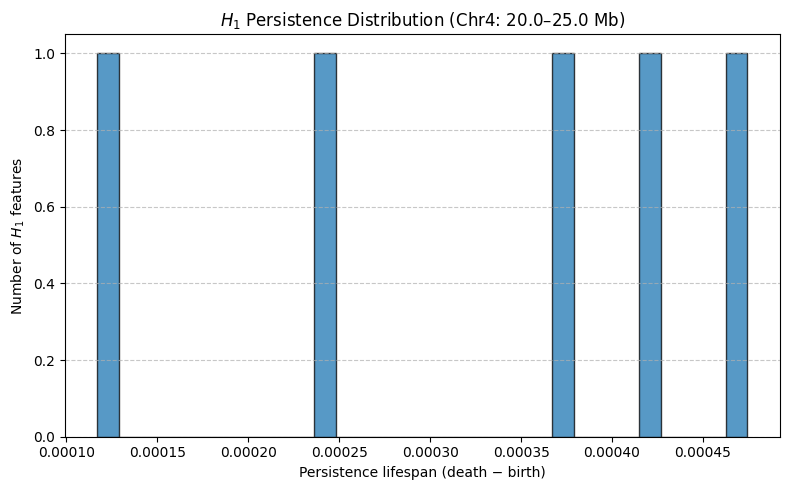

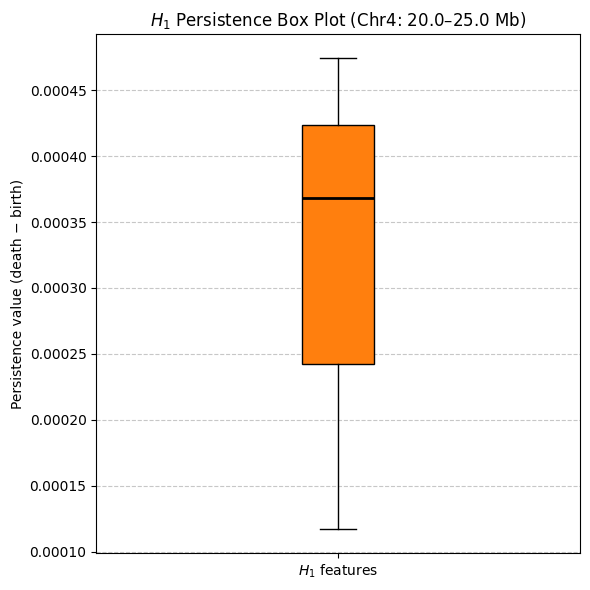

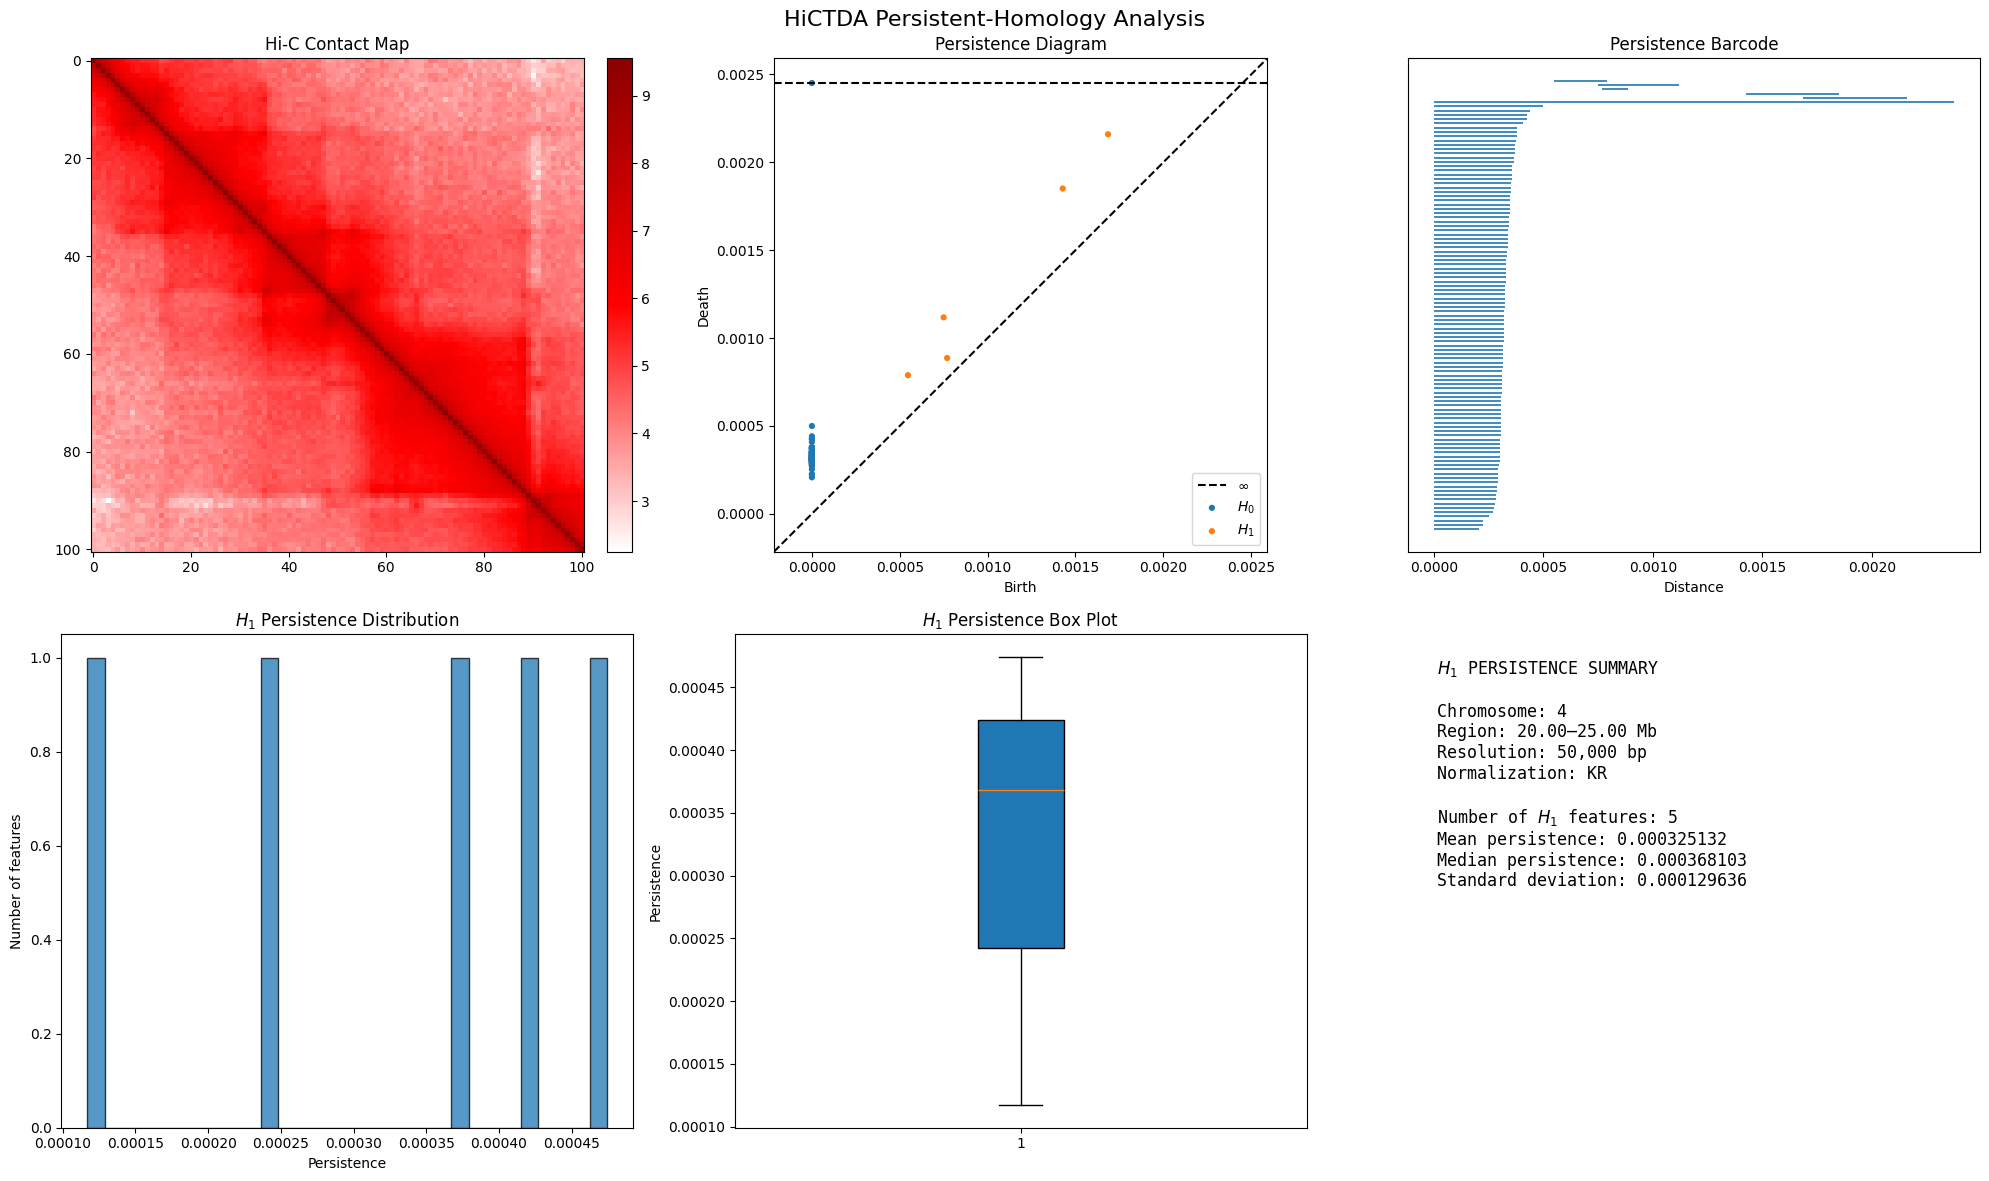

In [5]:
import hictda.io

# Patch the _find_chromosome function to correct the AttributeError
def _find_chromosome_patched(hic, chromosome: str):
    target = str(chromosome).replace("chr", "").lower()
    # The hic.getChromosomes() method already returns a list, no need for .chromosomes
    for c in hic.getChromosomes():
        name = str(c.name)
        normalized = name.replace("chr", "").lower()
        if normalized == target:
            return c
    raise ValueError(f"Chromosome '{chromosome}' not found.")

hictda.io._find_chromosome = _find_chromosome_patched

# Now import analyze_hic and call it as intended
from hictda import analyze_hic

results = analyze_hic(
    hic_file="https://www.encodeproject.org/files/ENCFF718AWL/@@download/ENCFF718AWL.hic",
    chromosome="4",
    start=20_000_000,
    end=25_000_000,
    resolution=50_000,
    normalization="KR",
    output_dir=""
)

print(results.statistics)

{'n_h1': 520, 'mean_persistence': 0.002344390821291689, 'median_persistence': 0.0015527969226241112, 'std_persistence': 0.0026954348138296296}


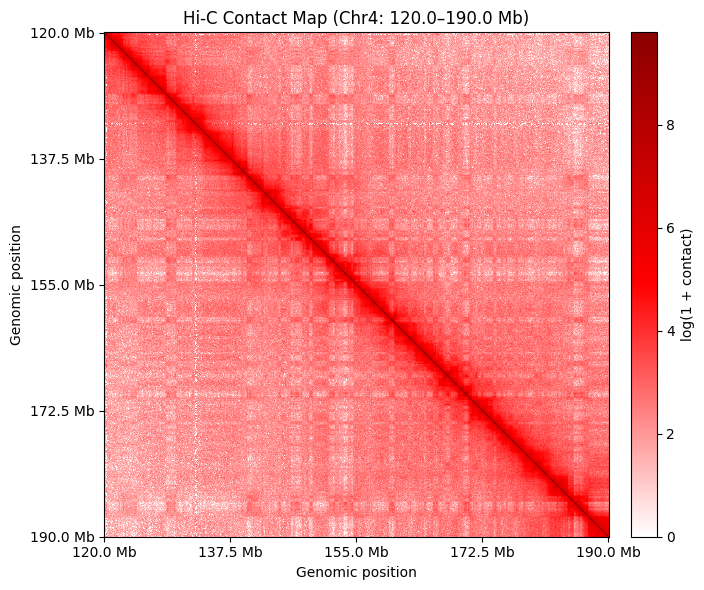

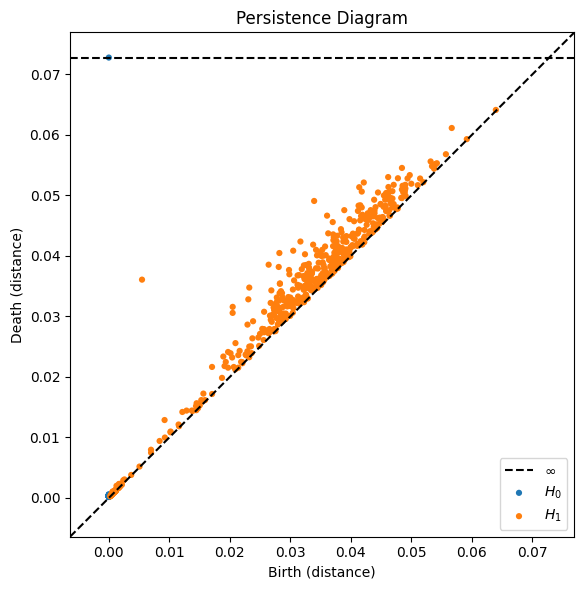

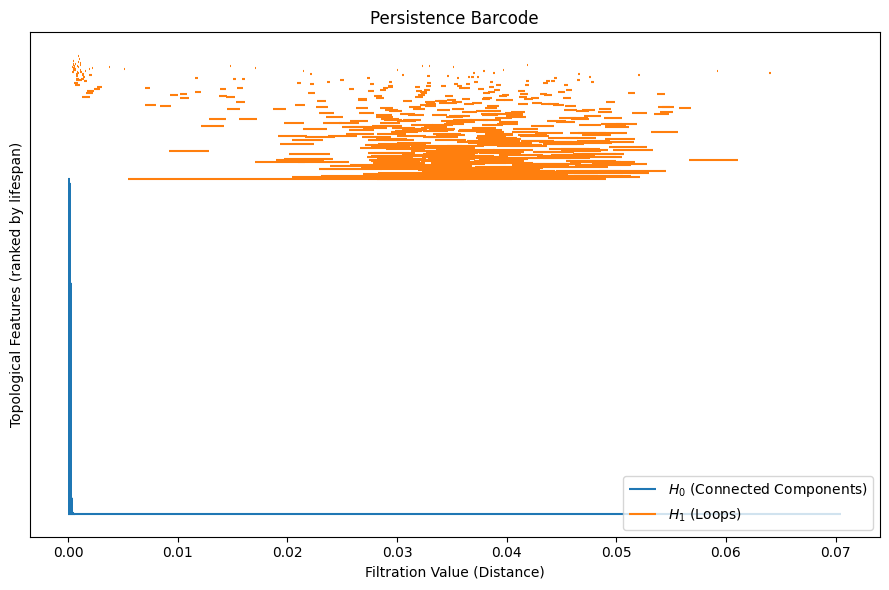

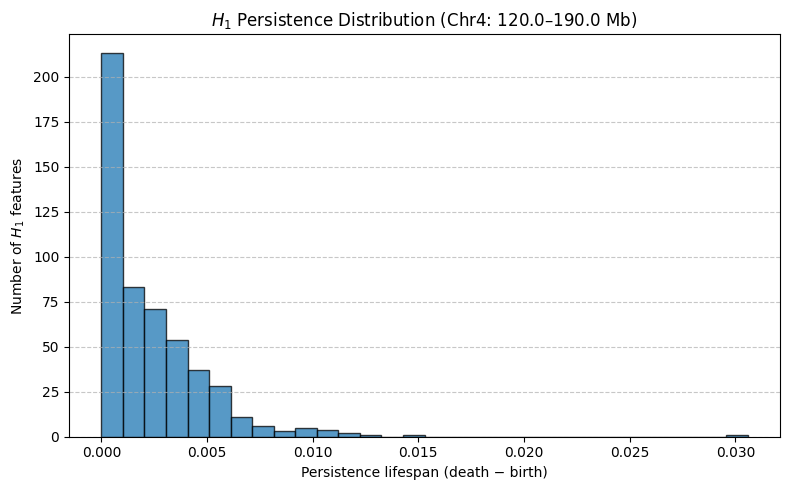

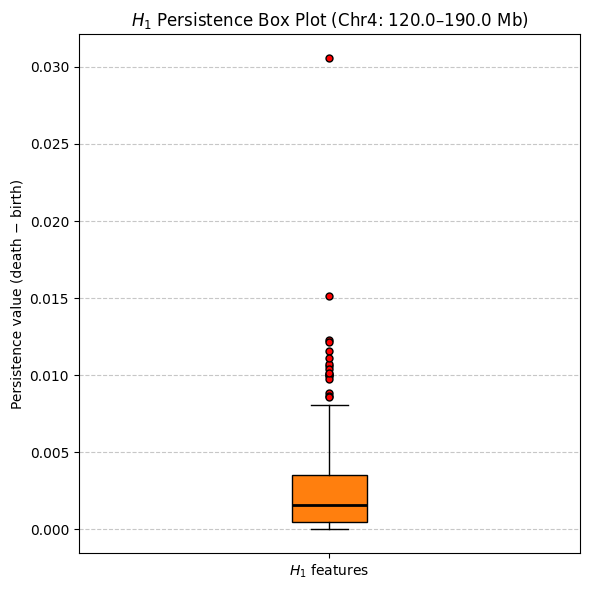

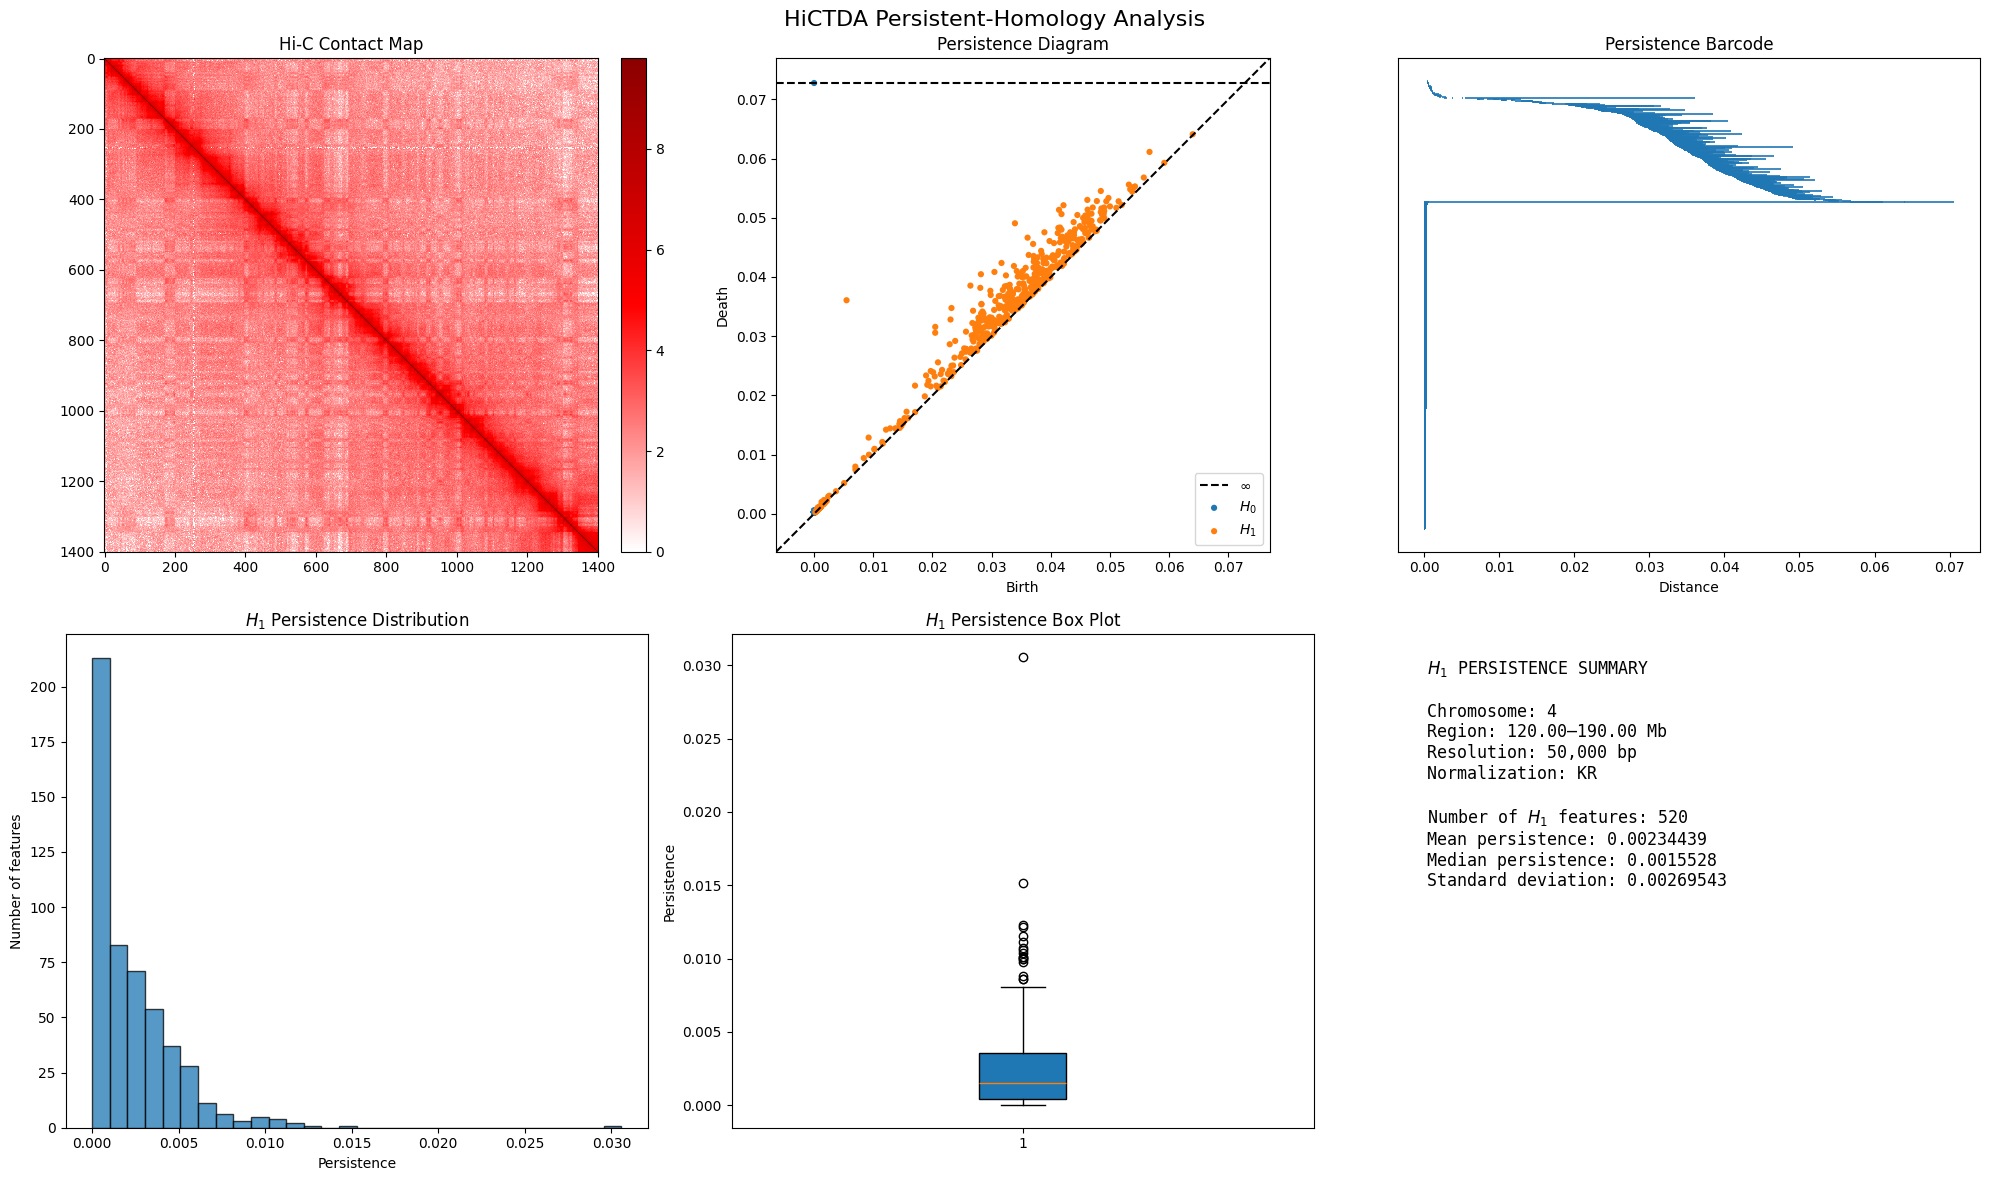

In [1]:
import hictda.io

# Patch the _find_chromosome function to correct the AttributeError
def _find_chromosome_patched(hic, chromosome: str):
    target = str(chromosome).replace("chr", "").lower()
    # The hic.getChromosomes() method already returns a list, no need for .chromosomes
    for c in hic.getChromosomes():
        name = str(c.name)
        normalized = name.replace("chr", "").lower()
        if normalized == target:
            return c
    raise ValueError(f"Chromosome '{chromosome}' not found.")

hictda.io._find_chromosome = _find_chromosome_patched

# Now import analyze_hic and call it as intended
from hictda import analyze_hic

results = analyze_hic(
    hic_file="https://www.encodeproject.org/files/ENCFF718AWL/@@download/ENCFF718AWL.hic",
    chromosome="4",
    start=120_000_000,
    end=190_000_000,
    resolution=50_000,
    normalization="KR",
    output_dir=""
)

print(results.statistics)